# Учимся работе с данными - от загрузки до моделирования

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_score

In [61]:
df = pd.read_csv('data.csv')
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [62]:
'''
1. id — Уникальный идентификационный номер пациента (не диагностический признак).

2. diagnosis — Диагноз: M (злокачественная опухоль) или B (доброкачественная).

3. radius_mean — Среднее значение радиуса опухоли (расстояние от центра до периметра).

4. texture_mean — Среднее значение текстуры (стандартное отклонение оттенков серого на изображении).

5. perimeter_mean — Среднее значение периметра опухоли.

6. area_mean — Среднее значение площади опухоли.

7. smoothness_mean — Средняя гладкость поверхности (локальные изменения радиуса).

8. compactness_mean — Средняя компактность (периметр² / площадь — 1.0).

9. concavity_mean — Средняя вогнутость (выраженность впадин на контуре).

10. concave points_mean — Среднее количество вогнутых участков на контуре.

11. symmetry_mean — Средняя симметричность формы опухоли.

12. fractal_dimension_mean — Средняя фрактальная размерность («неровность» края).

13. radius_se — Стандартная ошибка радиуса (вариабельность размера).

14. texture_se — Стандартная ошибка текстуры.

15. perimeter_se — Стандартная ошибка периметра.

16. area_se — Стандартная ошибка площади.

17. smoothness_se — Стандартная ошибка гладкости.

18. compactness_se — Стандартная ошибка компактности.

19. concavity_se — Стандартная ошибка вогнутости.

20. concave points_se — Стандартная ошибка количества вогнутых точек.

21. symmetry_se — Стандартная ошибка симметричности.

22. fractal_dimension_se — Стандартная ошибка фрактальной размерности.

23. radius_worst — Наибольшее (худшее) значение радиуса среди всех измерений.

24. texture_worst — Наибольшее значение текстуры.

25. perimeter_worst — Наибольшее значение периметра.

26. area_worst — Наибольшее значение площади.

27. smoothness_worst — Наибольшее значение гладкости.

28. compactness_worst — Наибольшее значение компактности.

29. concavity_worst — Наибольшее значение вогнутости.

30. concave points_worst — Наибольшее количество вогнутых точек.

31. symmetry_worst — Наибольшее значение симметричности.

32. fractal_dimension_worst — Наибольшее значение фрактальной размерности.

Примечание: столбец Unnamed: 32 в реальных данных пустой (это артефакт от CSV-файла), поэтому я его не описывал. Всего содержательных признаков — 31 (с 3-го по 32-й, исключая ID и диагноз).

'''

'\n1. id — Уникальный идентификационный номер пациента (не диагностический признак).\n\n2. diagnosis — Диагноз: M (злокачественная опухоль) или B (доброкачественная).\n\n3. radius_mean — Среднее значение радиуса опухоли (расстояние от центра до периметра).\n\n4. texture_mean — Среднее значение текстуры (стандартное отклонение оттенков серого на изображении).\n\n5. perimeter_mean — Среднее значение периметра опухоли.\n\n6. area_mean — Среднее значение площади опухоли.\n\n7. smoothness_mean — Средняя гладкость поверхности (локальные изменения радиуса).\n\n8. compactness_mean — Средняя компактность (периметр² / площадь — 1.0).\n\n9. concavity_mean — Средняя вогнутость (выраженность впадин на контуре).\n\n10. concave points_mean — Среднее количество вогнутых участков на контуре.\n\n11. symmetry_mean — Средняя симметричность формы опухоли.\n\n12. fractal_dimension_mean — Средняя фрактальная размерность («неровность» края).\n\n13. radius_se — Стандартная ошибка радиуса (вариабельность размер

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [64]:
df.describe()
# Удалить Unnamed 32 - лишний столбец и ID - не участвует в моделе
# Пустых значений нет
# Сильных выбросов нет, но распеределение надо посмотреть на графиках

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [65]:
# Удаляем столбец Unnamed: 32 так как он не участвует в расчете
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

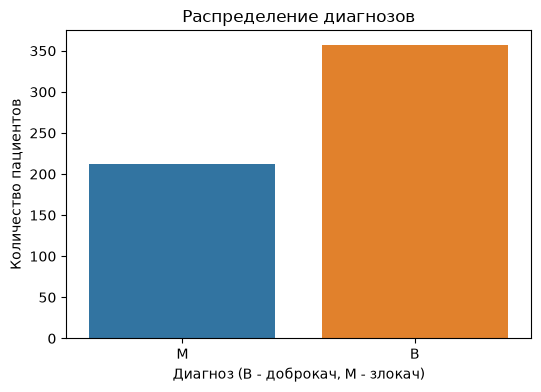

In [66]:
# Гистограмма целевой переменной

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis')
plt.title('Распределение диагнозов')
plt.xlabel('Диагноз (B - доброкач, M - злокач)')
plt.ylabel('Количество пациентов')
plt.show()

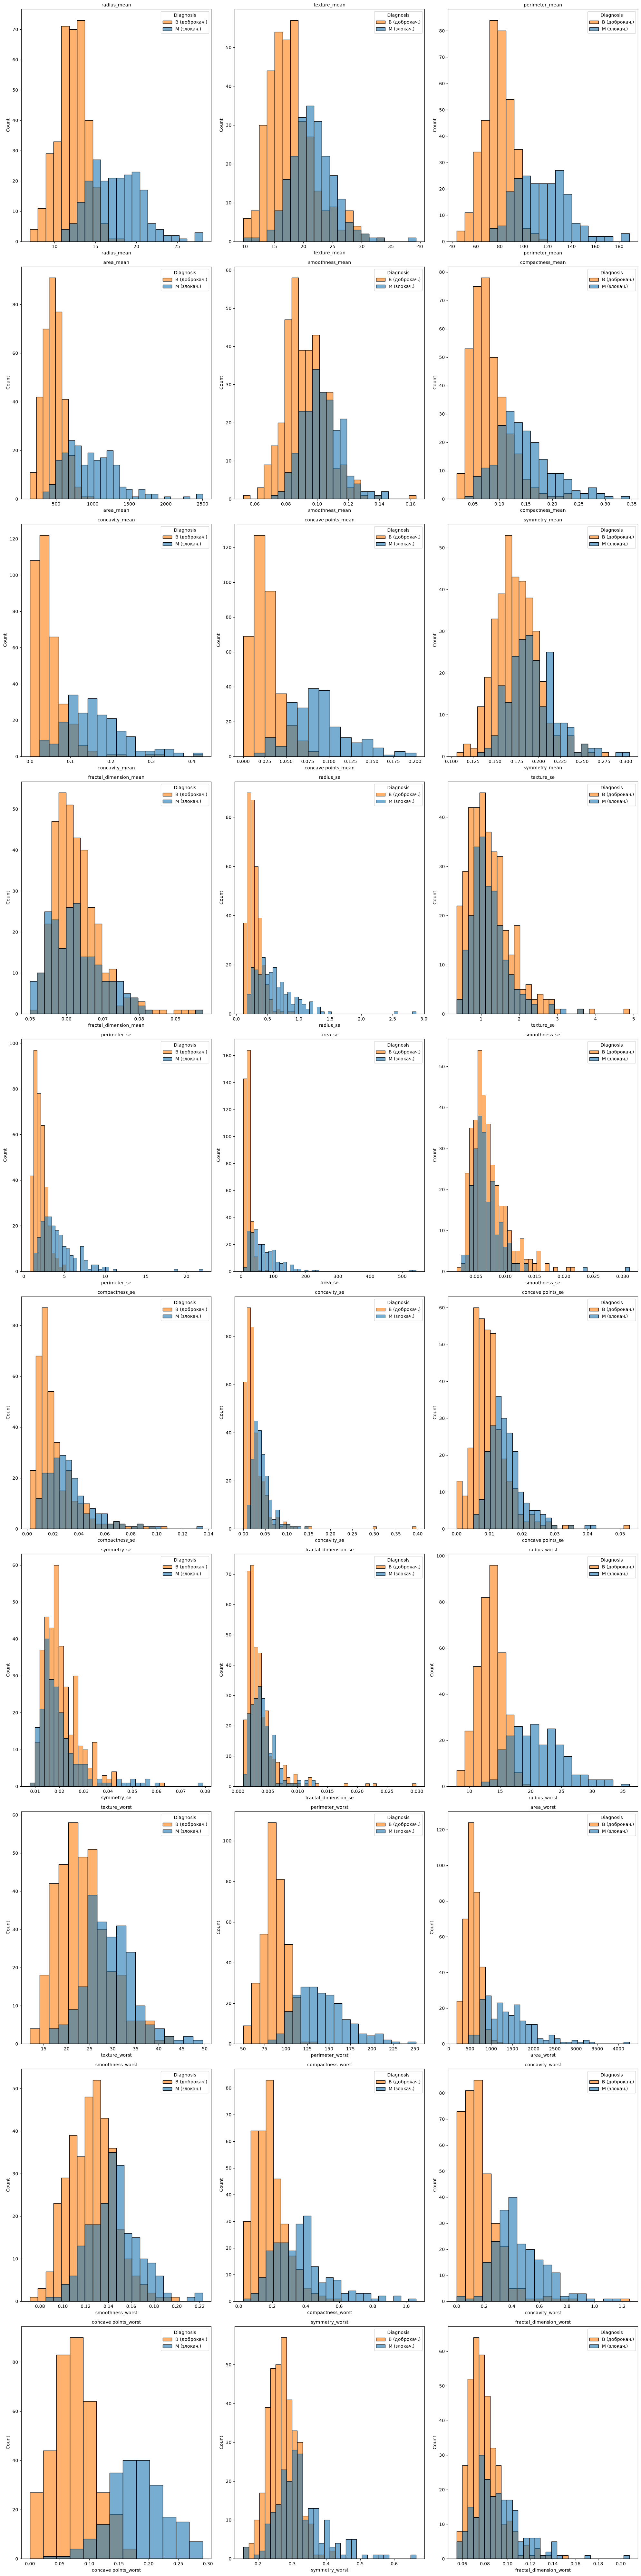

In [67]:
# Гистограммы признаков
features = df.drop('diagnosis', axis=1)

fig, axes = plt.subplots(10, 3, figsize=(20, 80))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    sns.histplot(data=df, x=col, hue='diagnosis', 
                 multiple='layer',
                 alpha=0.6,
                 ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(title='Diagnosis', labels=['B (доброкач.)', 'M (злокач.)'])

plt.tight_layout()
plt.show()

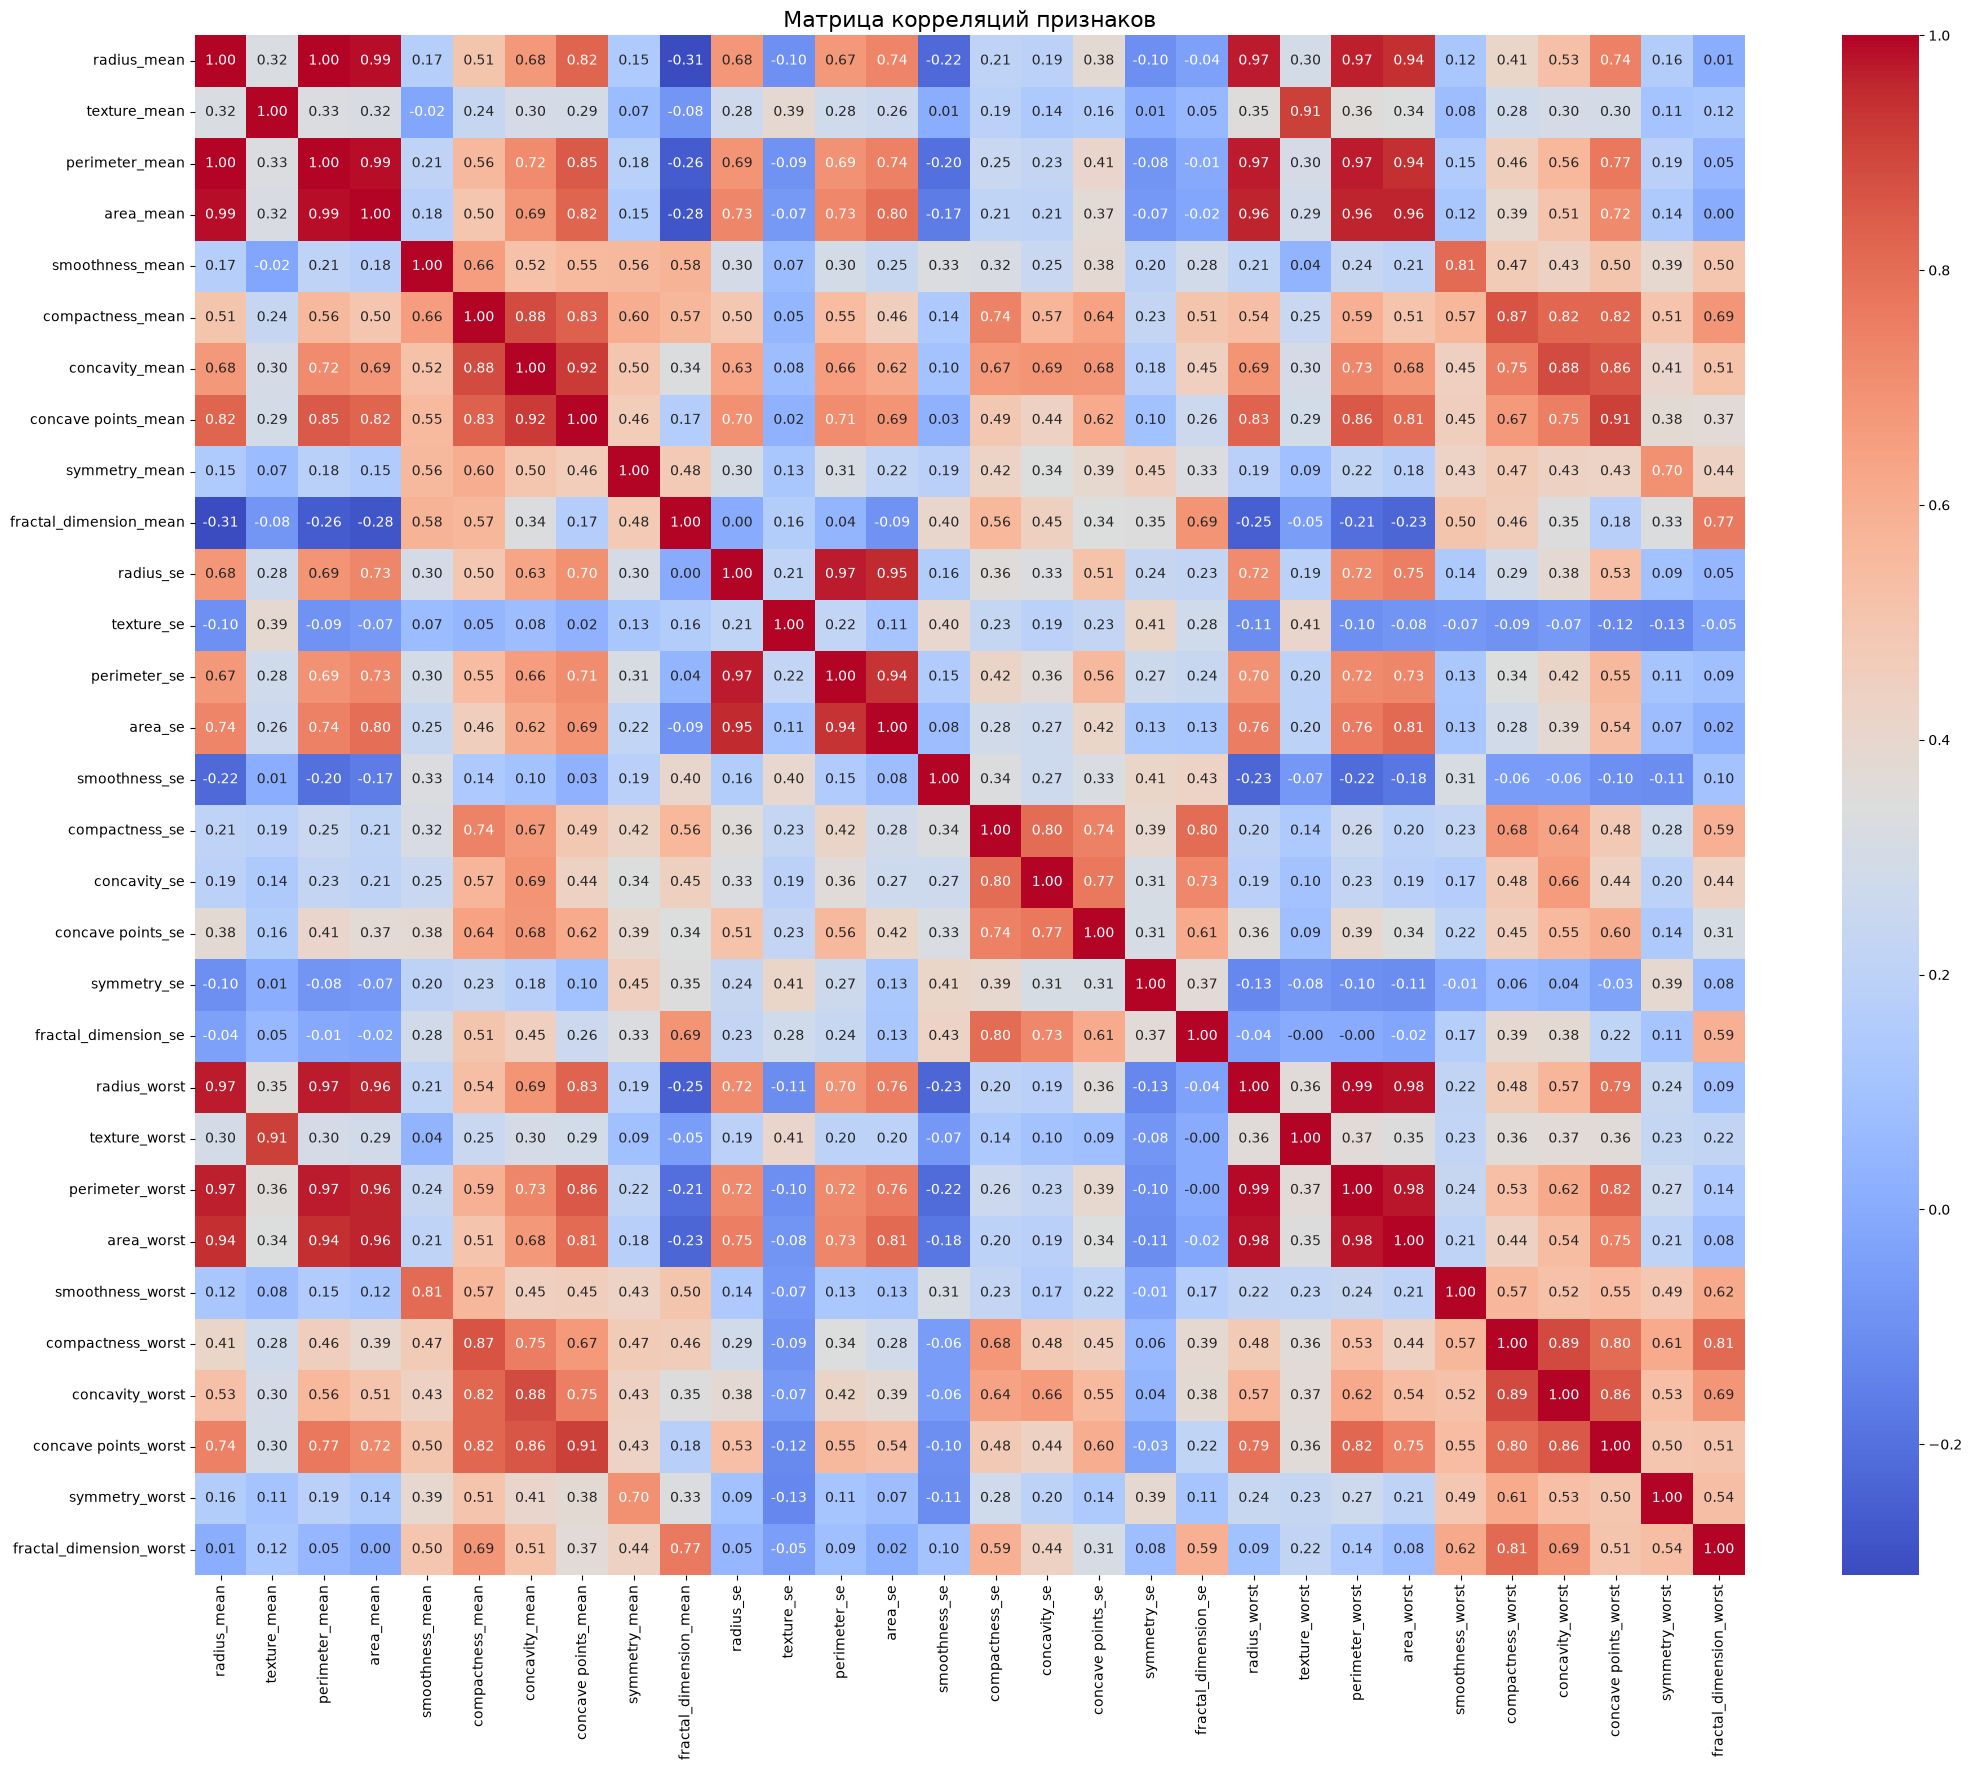

In [68]:
# Делаем тепловую карту и ищем сильно скоррелированные признаки

numeric_df = df.drop('diagnosis', axis=1)

plt.figure(figsize=(25, 20))
sns.heatmap(numeric_df.corr(), 
            annot=True,
            fmt='.2f', 
            cmap='coolwarm', 
           )
plt.title('Матрица корреляций признаков', fontsize=16)
plt.show()

# Скоррелированных признаком очень много.
# Самые крупные:
# radius mean - perimeter mean 
# area mean - radius mean
# radius worst - perimeter worst 
# area worst - radius worst



In [69]:
Построим парный 
pairs = [
    ('radius_mean', 'perimeter_mean'),
    ('area_mean', 'radius_mean'),
    ('radius_worst', 'perimeter_worst'),
    ('area_worst', 'radius_worst')
]

# Строим scatterplot'ы
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (col1, col2) in enumerate(pairs):
    sns.scatterplot(data=df, x=col1, y=col2, hue='diagnosis', 
                    alpha=0.7, s=60, ax=axes[i])
    corr = df[col1].corr(df[col2])
    axes[i].set_title(f'{col1} vs {col2}\nКорреляция = {corr:.3f}', fontsize=12)
    axes[i].legend(title='Диагноз')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1283219204.py, line 1)

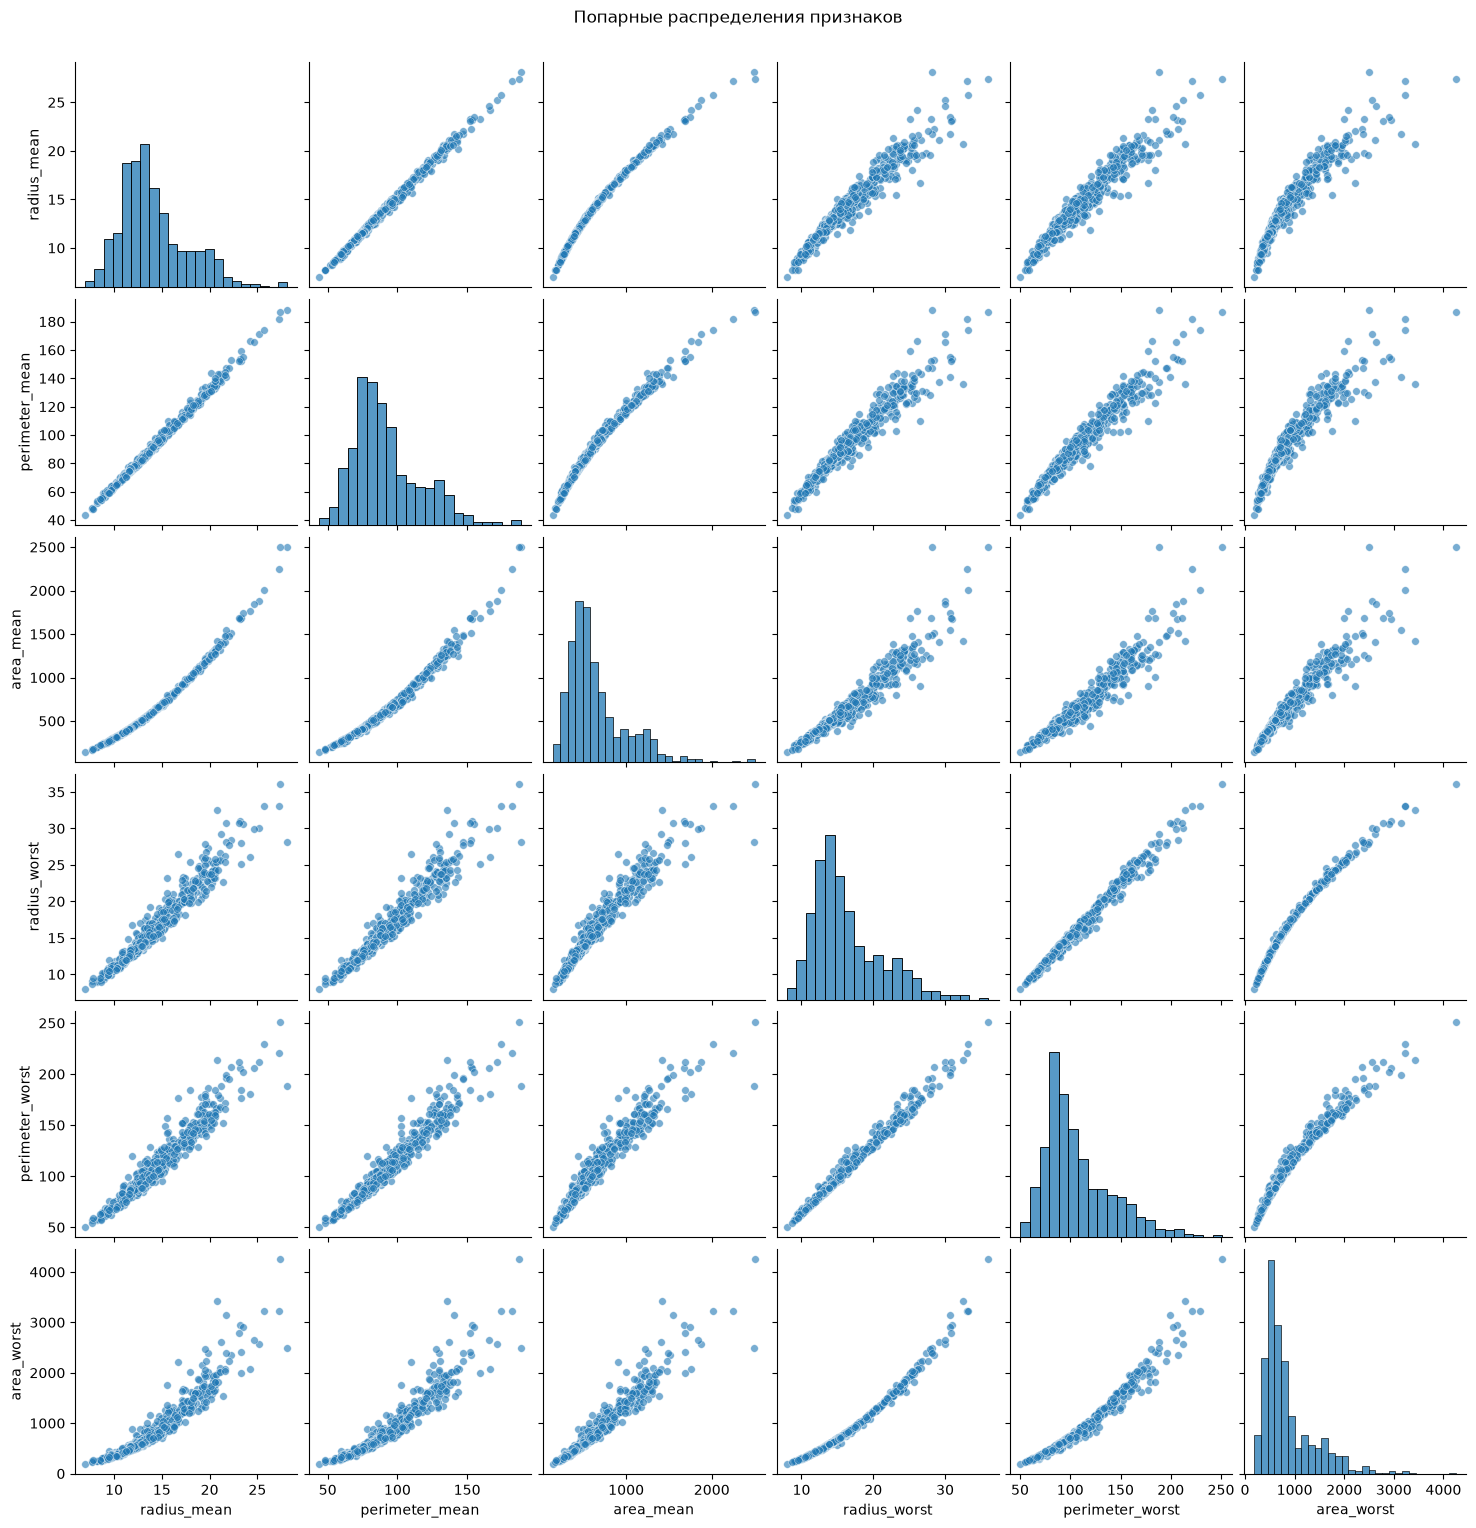

In [ ]:
# Выбираем признаки для pairplot
features = ['radius_mean', 'perimeter_mean', 'area_mean', 
            'radius_worst', 'perimeter_worst', 'area_worst']

# Строим pairplot с раскраской по диагнозу
sns.pairplot(df[features], 
             diag_kind='hist',  # на диагонали гистограммы
             plot_kws={'alpha': 0.6, 's': 30})

plt.suptitle('Попарные распределения признаков', y=1.02)
plt.show()

# Наблюдается очень сильная корреляция

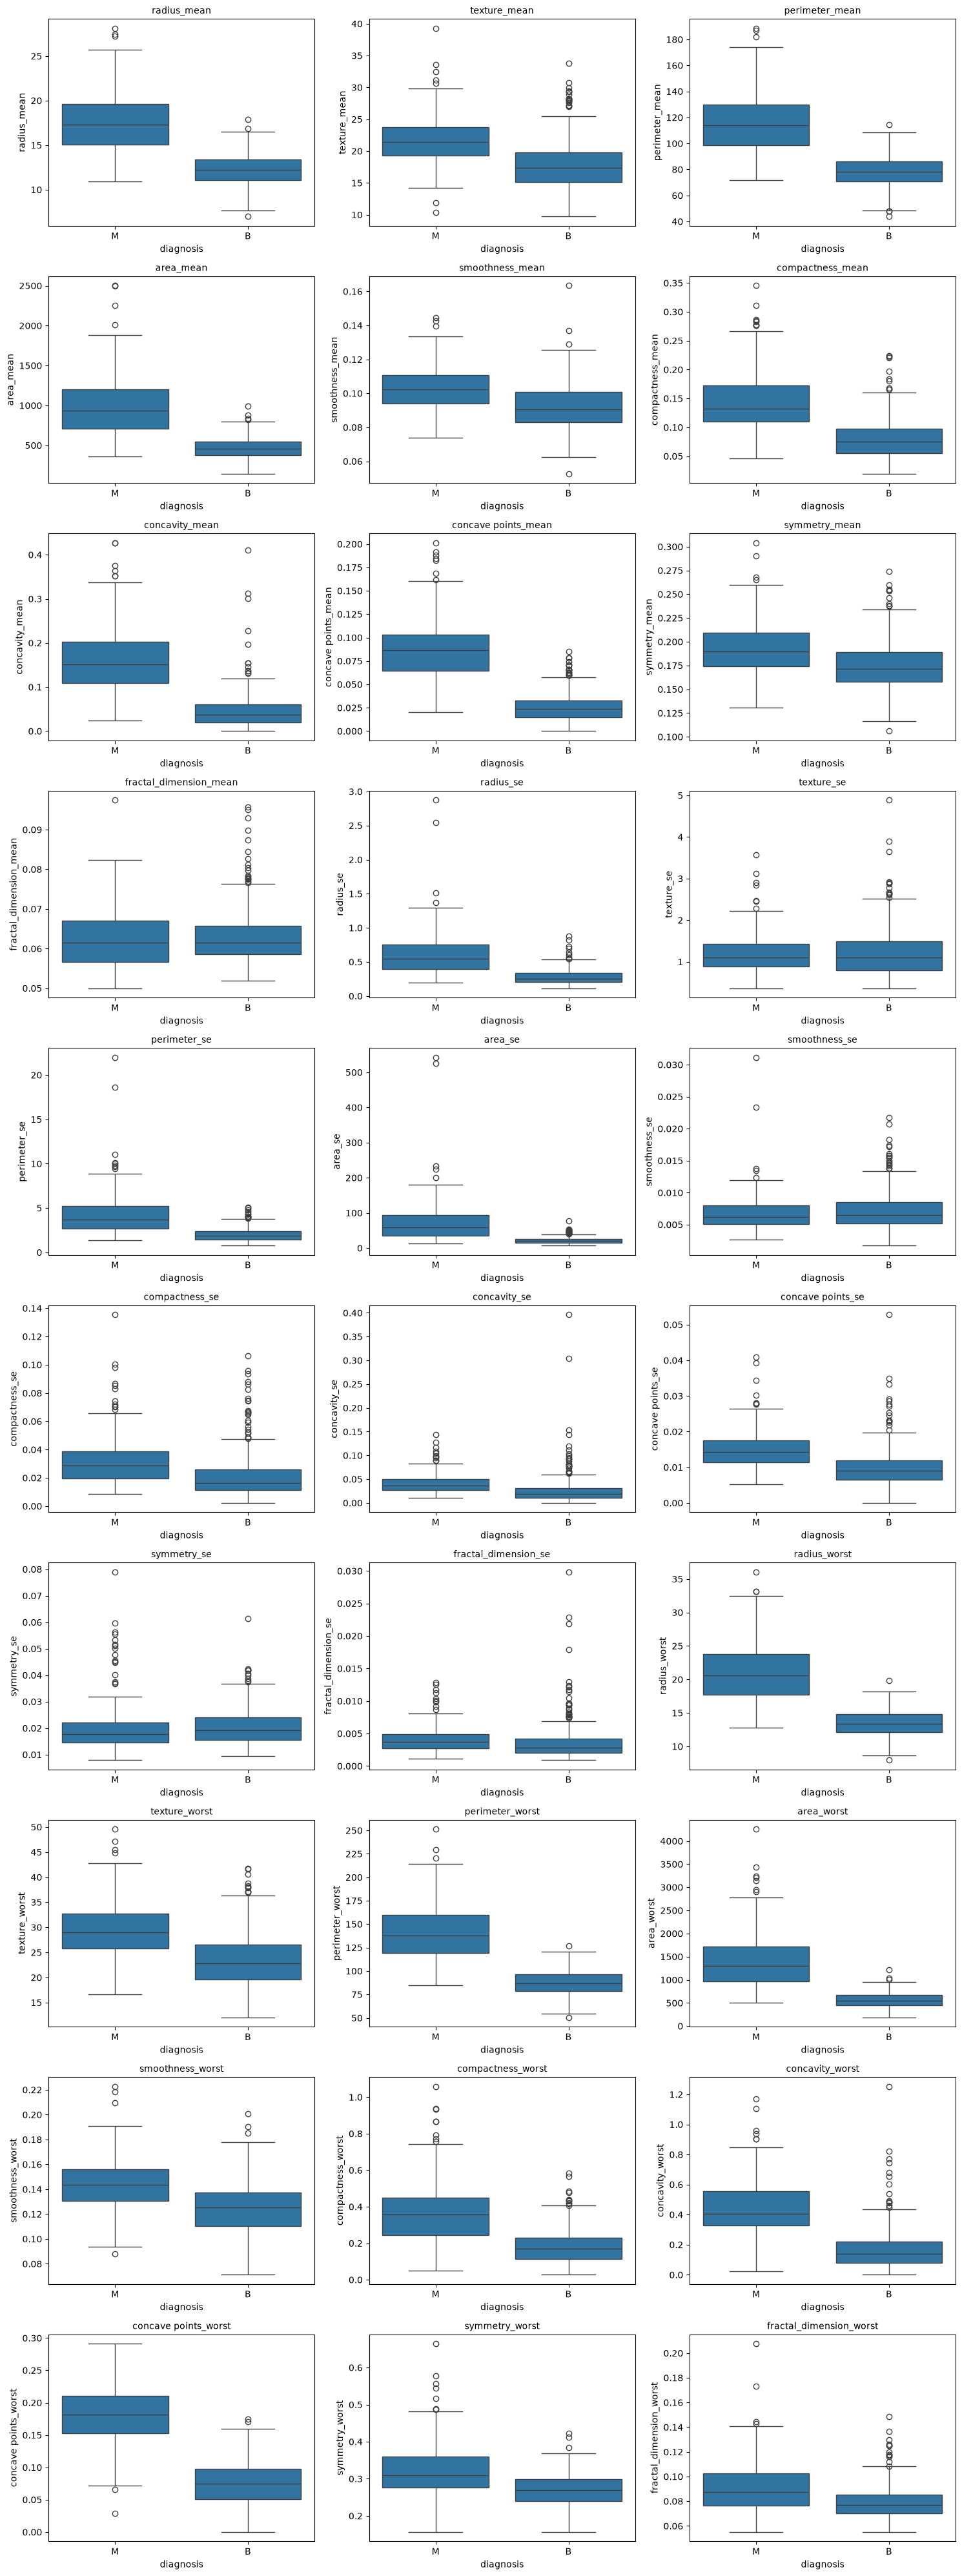

In [ ]:
# Рисуем boxplot'ы для всех признаков
features = df.drop('diagnosis', axis=1)

fig, axes = plt.subplots(10, 3, figsize=(15, 40))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()


# Наиболее удобные признаки для разделения: 
# radius_mean, perimeter_mean, area_mean, radius_worst, perimeter_worst, area_worst, concavity_mean, concave points_mean



In [147]:
# Разбивка данных а train-test, отложив 30% выборки для тестирования.

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [148]:
# Масштабирование данных
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Если не делать масштабирование, то больше значения буду оказывать сильное влияние на результат, нежели малые числа. 

In [149]:
# knn из коробки
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

In [150]:
# метрики

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='M')
recall = recall_score(y_test, y_pred, pos_label='M')
f1 = f1_score(y_test, y_pred, pos_label='M')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


Accuracy: 0.9590643274853801
Precision: 0.9516129032258065
Recall: 0.9365079365079365
F1-score: 0.944


AUC-ROC: 0.979


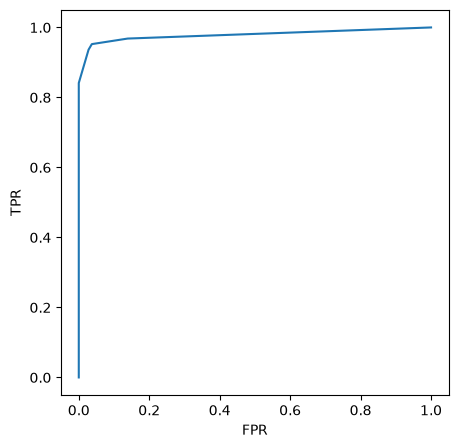

In [151]:
# Рисуем ROC кривую 

fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label='M')
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {roc_auc:.3f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [152]:
# Настройка параметра числа соседей на кросс-валидации

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f'Оптимальное кол-во соседей - {best_k}!')

Оптимальное кол-во соседей - 3!


In [153]:
# Проверяем результаты с лучшим best_k

knn_best = KNeighborsClassifier(n_neighbors=best_k)

knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)
y_pred_proba_best = knn_best.predict_proba(X_test_scaled)[:, 1]


accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label='M')
recall_best = recall_score(y_test, y_pred_best, pos_label='M')
f1_best = f1_score(y_test, y_pred_best, pos_label='M')

print(f"Accuracy_best: {accuracy_best}")
print(f"Precision_best: {precision_best}")
print(f"Recall_best: {recall_best}")
print(f"F1-score_best: {f1_best}")



Accuracy_best: 0.9590643274853801
Precision_best: 0.9516129032258065
Recall_best: 0.9365079365079365
F1-score_best: 0.944


In [ ]:
metrics = {
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'k=5 (без настройки)': [accuracy, precision, recall, f1],
    f'k={best_k} (настроенная)': [accuracy_best, precision_best, recall_best, f1_best],
    'Разница': [accuracy_best - accuracy, precision_best - precision,recall_best - recall, f1_best - f1]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

# Вывод: для 5 и для 3 метрики получаются одинаковые. Так как выборка небольшая результат не поменялся. Если менять число соседей или объем тестовой выборки, то разница становится более очевидной.


,Метрика,k=5 (без настройки),k=3 (настроенная),Разница
0,Accuracy,0.959064,0.959064,0.0
1,Precision,0.951613,0.951613,0.0
2,Recall,0.936508,0.936508,0.0
3,F1-score,0.944000,0.944000,0.0
